# Chapter 1 - Giving Computers the Ability to Learn from Data

## Core question

How can we translate a real problem into a machine-learning task, represent its data precisely, and design a workflow whose final evaluation still means what we claim it means?

Chapter 1 provides the vocabulary and mathematical notation used throughout the course. It does not ask you to master a particular learning algorithm. Chapter 2 will use this foundation to derive and implement the perceptron and Adaline classifiers.

### Learning outcomes

After completing this chapter, you should be able to:

1. distinguish supervised, unsupervised, and reinforcement learning from the information available during learning;
2. distinguish classification from regression by the type of target being predicted;
3. represent observations, features, and targets with the matrix notation used in the textbook;
4. explain clustering and dimensionality reduction without pretending that unknown labels are known;
5. trace the boundary between training, model selection, final testing, and prediction on new data;
6. identify a concrete route by which preprocessing can leak test information; and
7. preserve enough version, data, and evaluation evidence for another person to inspect a result.

The notebook is designed for independent reading. Run it from top to bottom in a fresh kernel. The figures are generated by the notebook; none is copied from the textbook.

## Notebook setup

The code uses only bundled or course-standard libraries and does not download data. The Iris dataset is loaded from scikit-learn. Every other dataset is explicitly labeled as synthetic teaching data.

In [1]:
# Run this setup cell before the demonstrations below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

RANDOM_SEED = 20260904
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 20)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Course random seed: {RANDOM_SEED}")

Course random seed: 20260904


## Issue 1 - What information does the learner receive?

Calling a system "machine learning" does not yet identify what it learns from. The first useful distinction is the signal available during learning.

| Learning type | Information available during learning | Typical result | What is not automatically available |
|---|---|---|---|
| Supervised learning | Inputs paired with known targets or labels | A function for predicting a target from new inputs | A guarantee that future data follow the training distribution |
| Unsupervised learning | Inputs without known targets | A grouping, lower-dimensional representation, or other description of structure | A correct external meaning for every discovered pattern |
| Reinforcement learning | States, actions, and reward signals obtained through interaction | A policy for choosing a sequence of actions | The correct action label for every state |

The categories answer different questions. A spam classifier trained from messages already labeled `spam` or `not spam` is supervised. A procedure that groups messages without those labels is unsupervised. An agent that chooses filtering actions and receives delayed rewards is a reinforcement-learning formulation only if actions, interaction, and reward are genuinely part of the problem.

### A precise supervised-learning statement

Let one observation have $m$ measured features. A supervised learner uses pairs

$$
(\mathbf{x}^{(i)},y^{(i)}),\qquad i=1,\ldots,n,
$$

where $\mathbf{x}^{(i)}$ contains the features of observation $i$ and $y^{(i)}$ is its known target during training. Learning produces a function $f$ that maps a new feature vector to a prediction:

$$
\hat y=f(\mathbf{x}).
$$

The hat in $\hat y$ matters: $\hat y$ is a model output, while $y$ is the observed target used for checking it. The function notation in this section is a course-added mathematical formulation of the textbook's verbal description.

### The supervised-learning process

The distinction between $y$ and $\hat y$ is also an information boundary. During fitting, labeled development observations provide both features and known targets. At prediction time, the fitted model receives features for a new observation, but its true target is not yet available. The target may become available later for evaluation, but it cannot be an input to the prediction it is supposed to check.

> **Before running the next cell:** In the process diagram, predict which two inputs are available during fitting and which one is unavailable when a new prediction is produced. Also predict whether the learning algorithm itself or the fitted model is applied to the new observation.

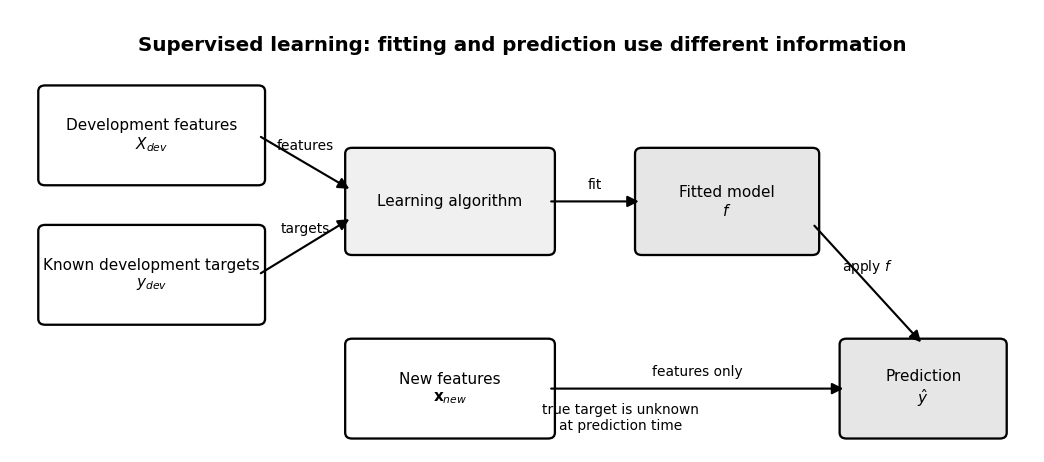

,phase,features available,known target available,object being used,result
0,Fit the model,Yes: X_dev,Yes: y_dev,Learning algorithm,Estimated model parameters
1,Produce a new prediction,Yes: x_new,"No, not at prediction time",Fitted model f,Prediction y_hat


In [2]:
# Course-added supervised-learning process diagram and phase table.
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

def process_box(x, y, width, height, text, facecolor="white", linestyle="-"):
    patch = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        edgecolor="black",
        facecolor=facecolor,
        linestyle=linestyle,
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=10)

def process_arrow(start, end, label=None):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=15, linewidth=1.4, color="black"))
    if label:
        ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.18, label, ha="center", fontsize=9)

process_box(0.4, 3.7, 2.5, 1.2, "Development features\n$X_{dev}$")
process_box(0.4, 1.8, 2.5, 1.2, "Known development targets\n$y_{dev}$")
process_box(4.0, 2.75, 2.3, 1.3, "Learning algorithm", facecolor="0.94")
process_box(7.4, 2.75, 2.0, 1.3, "Fitted model\n$f$", facecolor="0.90")
process_box(4.0, 0.25, 2.3, 1.2, "New features\n$\\mathbf{x}_{new}$")
process_box(9.8, 0.25, 1.8, 1.2, "Prediction\n$\\hat y$", facecolor="0.90")

process_arrow((2.9, 4.3), (4.0, 3.55), "features")
process_arrow((2.9, 2.4), (4.0, 3.18), "targets")
process_arrow((6.3, 3.4), (7.4, 3.4), "fit")
process_arrow((9.4, 3.1), (10.7, 1.45), "apply $f$")
process_arrow((6.3, 0.85), (9.8, 0.85), "features only")

ax.text(6.0, 5.45, "Supervised learning: fitting and prediction use different information", ha="center", fontsize=13, weight="bold")
ax.text(7.15, 0.25, "true target is unknown\nat prediction time", ha="center", va="bottom", fontsize=9)
plt.show()

phase_table = pd.DataFrame(
    {
        "phase": ["Fit the model", "Produce a new prediction"],
        "features available": ["Yes: X_dev", "Yes: x_new"],
        "known target available": ["Yes: y_dev", "No, not at prediction time"],
        "object being used": ["Learning algorithm", "Fitted model f"],
        "result": ["Estimated model parameters", "Prediction y_hat"],
    }
)
display(phase_table)

The diagram and table show that fitting uses both `X_dev` and `y_dev`, whereas a new prediction uses `x_new` without its unknown target. The learning algorithm estimates the fitted model $f$; the fitted model, not a new fitting operation, is then applied to the new observation. This diagram describes the information flow of supervised learning. It does not show how a particular algorithm estimates its parameters.

**Reasoning check.** A retailer has transaction records but no agreed definition of customer segments. Is clustering automatically useful? State what external evidence would be needed before attaching business meaning to the groups.

## Issue 2 - Does the target name a category or measure a quantity?

Supervised learning contains two central task types. The equations below are course-added formulations that make the textbook's verbal descriptions and regression figure explicit.

### Classification

For $K$ possible class labels, a classifier maps a feature vector to one label:

$$
f:\mathbb{R}^{m}\rightarrow\{c_1,c_2,\ldots,c_K\}.
$$

The labels are categories, not numerical distances. If `Setosa`, `Versicolor`, and `Virginica` are encoded as 0, 1, and 2, the code does not make `Virginica` twice `Versicolor`. Binary classification has two possible classes; multiclass classification has more than two.

### Regression

A regression model predicts a continuous quantity:

$$
f:\mathbb{R}^{m}\rightarrow\mathbb{R}.
$$

A linear prediction with $m$ features can be written as

$$
\hat y=\mathbf{w}^{\mathsf T}\mathbf{x}+b
=\sum_{j=1}^{m}w_jx_j+b.
$$

Here, $\mathbf{w}$ contains one fitted weight per feature and $b$ is the intercept. For observation $i$, the residual is

$$
e^{(i)}=y^{(i)}-\hat y^{(i)}.
$$

The chapter describes fitting a line by minimizing average squared distance. Written as mean squared error (MSE), that idea is

$$
\operatorname{MSE}=\frac{1}{n}\sum_{i=1}^{n}\left(y^{(i)}-\hat y^{(i)}\right)^2.
$$

This formulation uses vertical residuals $y^{(i)}-\hat y^{(i)}$, as in ordinary least-squares regression, and requires $n>0$. Squaring prevents positive and negative residuals from canceling and gives large residuals greater influence. MSE has squared target units: if $y$ is measured in points, MSE is measured in points squared. In the linear equation, $b$ has target units, while $w_j$ has target units per unit of feature $j$. The equation assumes that the represented feature effects enter through this additive linear form; it does not establish causation.

> **Before running the next cell:** Predict the class assigned to the marked point by the displayed illustrative boundary. For the regression panel, predict whether the largest absolute residual will necessarily occur at the largest $x$ value.

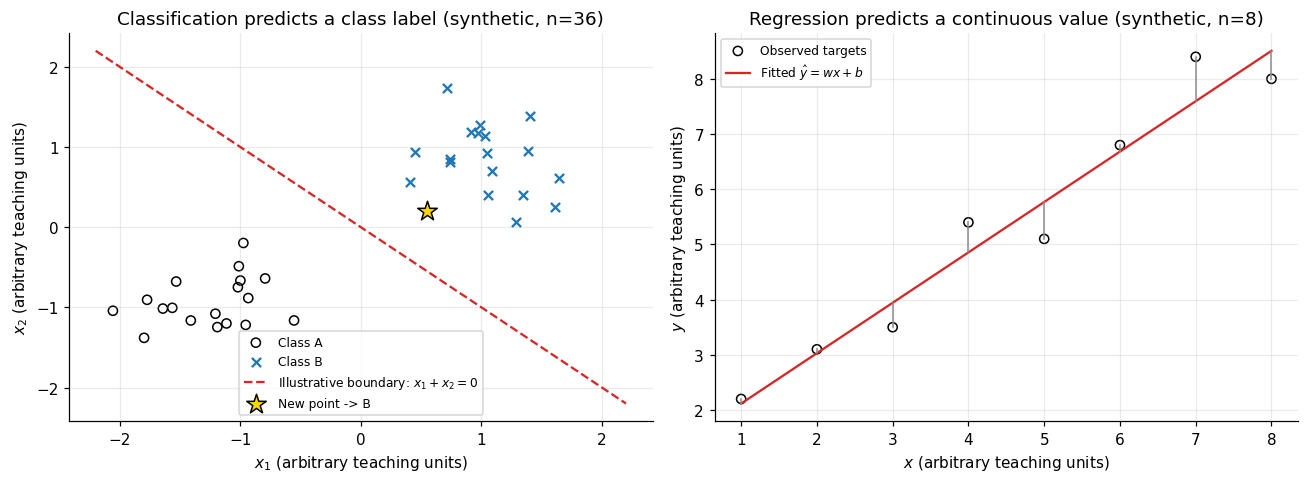

,quantity,observed value
0,new-point class,B
1,intercept b,1.204
2,slope w,0.913
3,MSE,0.234
4,largest |residual| at x,7.0


In [3]:
# Course-added synthetic examples: they illustrate task structure, not real observations.
rng = np.random.default_rng(7)

class_a = rng.normal(loc=(-1.0, -0.8), scale=(0.42, 0.45), size=(18, 2))
class_b = rng.normal(loc=(1.0, 0.9), scale=(0.45, 0.42), size=(18, 2))
new_point = np.array([0.55, 0.20])
new_class = "B" if new_point.sum() > 0 else "A"

x_reg = np.arange(1.0, 9.0)
y_reg = np.array([2.2, 3.1, 3.5, 5.4, 5.1, 6.8, 8.4, 8.0])
design = np.column_stack([np.ones_like(x_reg), x_reg])
b, w = np.linalg.lstsq(design, y_reg, rcond=None)[0]
y_hat = b + w * x_reg
residual = y_reg - y_hat
mse = np.mean(residual**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(class_a[:, 0], class_a[:, 1], marker="o", facecolors="none", edgecolors="black", label="Class A")
axes[0].scatter(class_b[:, 0], class_b[:, 1], marker="x", color="tab:blue", label="Class B")
boundary_x = np.linspace(-2.2, 2.2, 100)
axes[0].plot(boundary_x, -boundary_x, linestyle="--", color="tab:red", label=r"Illustrative boundary: $x_1+x_2=0$")
axes[0].scatter(*new_point, marker="*", s=180, color="gold", edgecolor="black", label=f"New point -> {new_class}")
axes[0].set(
    xlabel="$x_1$ (arbitrary teaching units)",
    ylabel="$x_2$ (arbitrary teaching units)",
    title="Classification predicts a class label (synthetic, n=36)",
)
axes[0].legend(fontsize=8)

axes[1].scatter(x_reg, y_reg, marker="o", facecolors="none", edgecolors="black", label="Observed targets")
axes[1].plot(x_reg, y_hat, color="tab:red", label=r"Fitted $\hat y=wx+b$")
for x_i, y_i, pred_i in zip(x_reg, y_reg, y_hat):
    axes[1].plot([x_i, x_i], [pred_i, y_i], color="0.55", linewidth=1)
axes[1].set(
    xlabel="$x$ (arbitrary teaching units)",
    ylabel="$y$ (arbitrary teaching units)",
    title="Regression predicts a continuous value (synthetic, n=8)",
)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "quantity": ["new-point class", "intercept b", "slope w", "MSE", "largest |residual| at x"],
        "observed value": [new_class, f"{b:.3f}", f"{w:.3f}", f"{mse:.3f}", f"{x_reg[np.argmax(np.abs(residual))]:.1f}"],
    }
)

The displayed boundary assigns the marked point to Class B because $0.55+0.20>0$. In the regression output, the fitted intercept is `1.204`, the slope is `0.913`, and MSE is `0.234`. The largest absolute residual occurs at $x=7.0$, not automatically at the largest $x$ value. A positive fitted slope does not establish that $x$ causes $y$ to increase.

**Reasoning check.** If a university encodes `first year`, `second year`, `third year`, and `fourth year` as 1-4, does that automatically make the task regression? Identify the target being predicted before deciding.

## Issue 3 - What can be learned without target labels?

### Clustering

Clustering seeks groups whose members are similar under declared features and a declared similarity rule. The textbook introduces this idea conceptually; the following Euclidean-distance equation is a course-added mathematical bridge:

$$
d\!\left(\mathbf{x}^{(a)},\mathbf{x}^{(b)}\right)
=\sqrt{\sum_{j=1}^{m}\left(x_j^{(a)}-x_j^{(b)}\right)^2}.
$$

The formula requires numeric feature representations and does not determine which features should be used or whether they should be scaled. Changing units can change the distances and therefore the groups. Cluster identifiers such as 0, 1, and 2 are arbitrary names; they are not known class labels.

### Dimensionality reduction

A dimensionality-reduction method maps an $m$-dimensional observation into $p$ dimensions, where $p<m$. The following function notation is a course-added formulation:

$$
g:\mathbb{R}^{m}\rightarrow\mathbb{R}^{p},\qquad
\mathbf{z}^{(i)}=g\!\left(\mathbf{x}^{(i)}\right).
$$

The new coordinates $\mathbf{z}^{(i)}$ may support visualization, compression, or later modeling. A lower-dimensional view necessarily leaves something out; whether it preserves the relationships needed for a particular decision must be checked rather than assumed.

### Reinforcement learning

An agent observes a state $s_t$, chooses an action $a_t$, and receives a reward $r_{t+1}$ as the environment changes. When rewards can be delayed, one common course-added mathematical description of the return from time $t$ is

$$
G_t=r_{t+1}+\gamma r_{t+2}+\gamma^2r_{t+3}+\cdots
=\sum_{k=0}^{T-t-1}\gamma^k r_{t+k+1},
$$

where $0\leq\gamma\leq1$ controls how strongly later rewards count. This equation makes delayed feedback explicit; it does not imply that every reinforcement-learning method uses the same horizon or return definition.

The next diagram separates the two directions of interaction: the agent sends an action to the environment, and the environment returns the next state and a reward. The accompanying synthetic reward sequence checks the discounted-return calculation with $\gamma=0.8$.

> **Before running the next cell:** Predict the discounted contribution of the reward $5$ received two steps later. Then predict whether the return is greater or less than the undiscounted sum $0-1+5=4$.

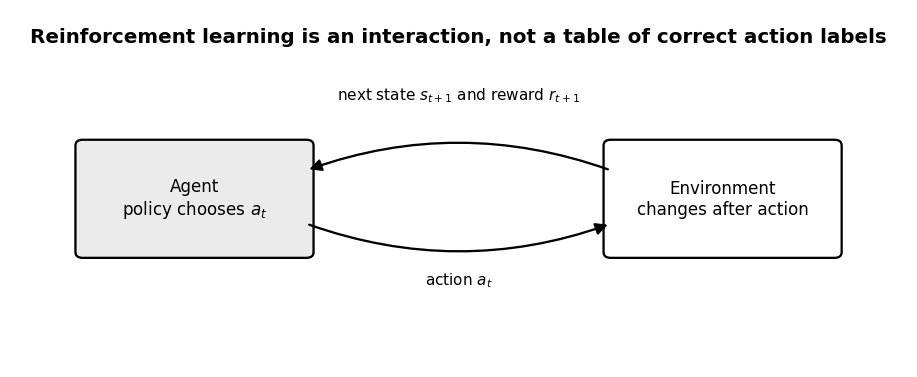

,step k,synthetic reward r_(t+k+1),discount weight gamma^k,discounted contribution
0,0,0.0,1.00,0.0
1,1,-1.0,0.80,-0.8
2,2,5.0,0.64,3.2


Discounted return G_t: 2.400


In [4]:
# Course-added reinforcement-learning interaction and synthetic reward calculation.
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

agent = FancyBboxPatch((0.8, 1.6), 2.5, 1.5, boxstyle="round,pad=0.08", edgecolor="black", facecolor="0.92", linewidth=1.5)
environment = FancyBboxPatch((6.7, 1.6), 2.5, 1.5, boxstyle="round,pad=0.08", edgecolor="black", facecolor="white", linewidth=1.5)
ax.add_patch(agent)
ax.add_patch(environment)
ax.text(2.05, 2.35, "Agent\npolicy chooses $a_t$", ha="center", va="center", fontsize=11)
ax.text(7.95, 2.35, "Environment\nchanges after action", ha="center", va="center", fontsize=11)

action_arrow = FancyArrowPatch((3.3, 2.0), (6.7, 2.0), connectionstyle="arc3,rad=0.18", arrowstyle="-|>", mutation_scale=16, linewidth=1.5, color="black")
feedback_arrow = FancyArrowPatch((6.7, 2.75), (3.3, 2.75), connectionstyle="arc3,rad=0.18", arrowstyle="-|>", mutation_scale=16, linewidth=1.5, color="black")
ax.add_patch(action_arrow)
ax.add_patch(feedback_arrow)
ax.text(5.0, 1.15, "action $a_t$", ha="center", fontsize=10)
ax.text(5.0, 3.75, "next state $s_{t+1}$ and reward $r_{t+1}$", ha="center", fontsize=10)
ax.text(5.0, 4.55, "Reinforcement learning is an interaction, not a table of correct action labels", ha="center", fontsize=13, weight="bold")
plt.show()

gamma = 0.8
rewards = np.array([0.0, -1.0, 5.0])
steps = np.arange(len(rewards))
weights = gamma ** steps
contributions = weights * rewards
reward_table = pd.DataFrame(
    {
        "step k": steps,
        "synthetic reward r_(t+k+1)": rewards,
        "discount weight gamma^k": weights,
        "discounted contribution": contributions,
    }
)
display(reward_table.round(3))
print(f"Discounted return G_t: {contributions.sum():.3f}")

With $\gamma=0.8$, the reward $5$ received at $k=2$ receives weight $0.8^2=0.64$ and contributes $3.2$ to the return. The penalty $-1$ at $k=1$ contributes $-0.8$, so the displayed return is $0-0.8+3.2=2.4$, which is less than the undiscounted sum $4$. These numbers are a synthetic calculation used to verify the formula; they are not results from a trained agent.

> **Before running the next cell:** Predict whether the cluster numbers will carry an ordering such as low, medium, and high. For the Swiss-roll example, predict which relationships the two-dimensional representation is intended to preserve.

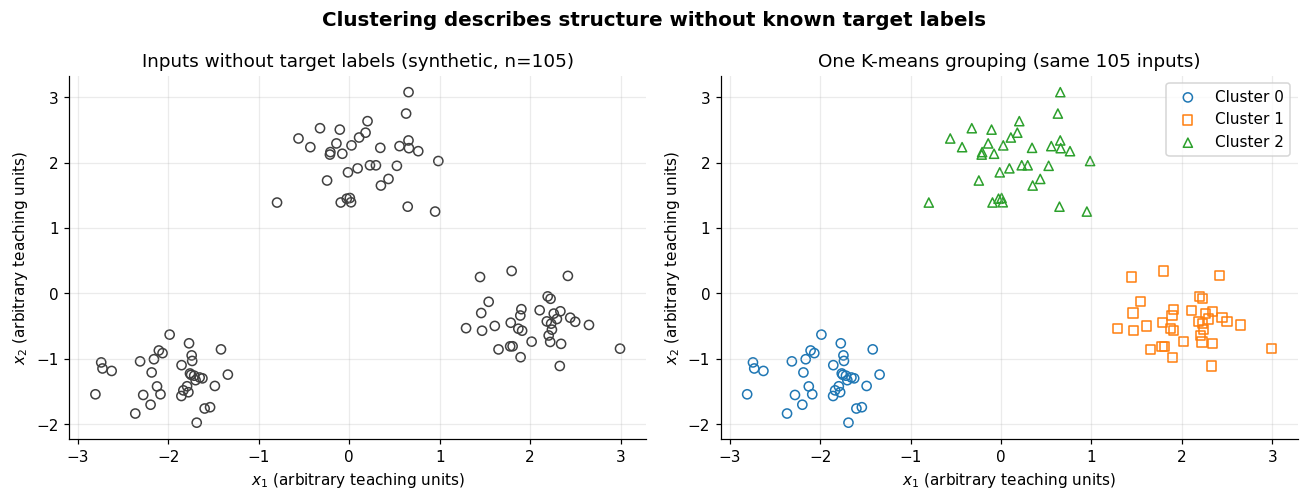

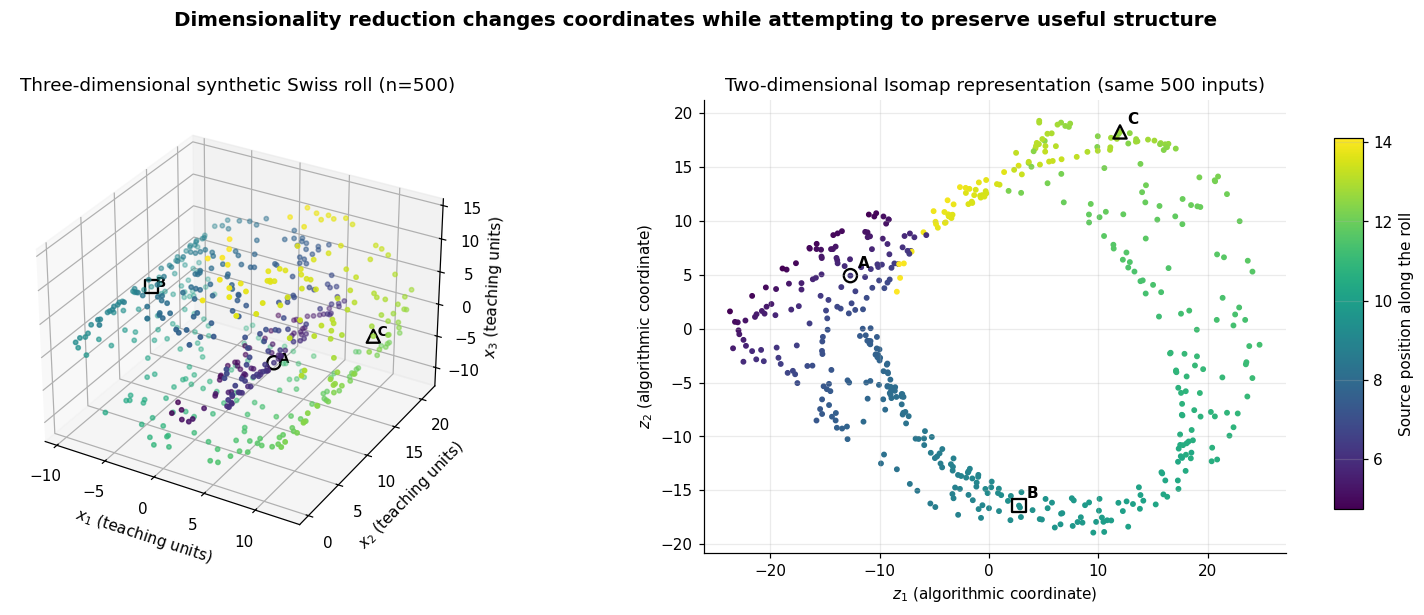

,observations
arbitrary cluster ID,
0,35
1,35
2,35


In [5]:
# Course-added demonstrations. Cluster data and the Swiss roll are synthetic teaching data.
from sklearn.cluster import KMeans
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import Isomap

rng = np.random.default_rng(11)
centers = np.array([[-2.0, -1.2], [0.1, 2.0], [2.1, -0.5]])
unlabeled = np.vstack([rng.normal(center, 0.42, size=(35, 2)) for center in centers])
cluster_id = KMeans(n_clusters=3, n_init=20, random_state=11).fit_predict(unlabeled)

swiss_x, swiss_position = make_swiss_roll(n_samples=500, noise=0.08, random_state=11)
swiss_z = Isomap(n_neighbors=10, n_components=2).fit_transform(swiss_x)

fig_cluster, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

ax1.scatter(unlabeled[:, 0], unlabeled[:, 1], facecolors="none", edgecolors="0.25")
ax1.set(
    title="Inputs without target labels (synthetic, n=105)",
    xlabel="$x_1$ (arbitrary teaching units)",
    ylabel="$x_2$ (arbitrary teaching units)",
)

markers = ["o", "s", "^"]
for k, marker in enumerate(markers):
    points = unlabeled[cluster_id == k]
    ax2.scatter(points[:, 0], points[:, 1], marker=marker, facecolors="none", edgecolors=f"C{k}", label=f"Cluster {k}")
ax2.set(
    title="One K-means grouping (same 105 inputs)",
    xlabel="$x_1$ (arbitrary teaching units)",
    ylabel="$x_2$ (arbitrary teaching units)",
)
ax2.legend()

fig_cluster.suptitle("Clustering describes structure without known target labels", fontsize=13, weight="bold")
fig_cluster.tight_layout()
plt.show()

fig_dimension = plt.figure(figsize=(14.5, 5.8))
ax3 = fig_dimension.add_subplot(1, 2, 1, projection="3d")
ax4 = fig_dimension.add_subplot(1, 2, 2)

p3 = ax3.scatter(swiss_x[:, 0], swiss_x[:, 1], swiss_x[:, 2], c=swiss_position, cmap="viridis", s=8)
ax3.set(
    title="Three-dimensional synthetic Swiss roll (n=500)",
    xlabel="$x_1$ (teaching units)",
    ylabel="$x_2$ (teaching units)",
    zlabel="$x_3$ (teaching units)",
)
ax3.set_zlabel("$x_3$ (teaching units)", labelpad=1)

p4 = ax4.scatter(swiss_z[:, 0], swiss_z[:, 1], c=swiss_position, cmap="viridis", s=8)
ax4.set(
    title="Two-dimensional Isomap representation (same 500 inputs)",
    xlabel="$z_1$ (algorithmic coordinate)",
    ylabel="$z_2$ (algorithmic coordinate)",
)

# Repeated shapes and labels provide three cross-panel anchors without relying only on color.
anchor_positions = np.quantile(swiss_position, [0.15, 0.50, 0.85])
anchor_indices = [int(np.argmin(np.abs(swiss_position - value))) for value in anchor_positions]
for label, marker, idx in zip(["A", "B", "C"], ["o", "s", "^"], anchor_indices):
    ax3.scatter(
        swiss_x[idx, 0], swiss_x[idx, 1], swiss_x[idx, 2],
        marker=marker, s=75, facecolors="none", edgecolors="black", linewidths=1.5,
    )
    ax3.text(swiss_x[idx, 0], swiss_x[idx, 1], swiss_x[idx, 2], f" {label}", fontsize=9, weight="bold")
    ax4.scatter(
        swiss_z[idx, 0], swiss_z[idx, 1],
        marker=marker, s=75, facecolors="none", edgecolors="black", linewidths=1.5,
    )
    ax4.annotate(label, (swiss_z[idx, 0], swiss_z[idx, 1]), xytext=(5, 5), textcoords="offset points", weight="bold")
fig_dimension.suptitle("Dimensionality reduction changes coordinates while attempting to preserve useful structure", fontsize=13, weight="bold")
fig_dimension.subplots_adjust(left=0.03, right=0.87, top=0.84, bottom=0.13, wspace=0.30)
colorbar_axis = fig_dimension.add_axes([0.90, 0.20, 0.018, 0.58])
fig_dimension.colorbar(p4, cax=colorbar_axis, label="Source position along the roll")
plt.show()

pd.Series(cluster_id).value_counts().sort_index().rename_axis("arbitrary cluster ID").to_frame("observations")

The table reports 35 observations assigned to each of cluster IDs 0, 1, and 2. Equal counts arise from this generated example; K-means does not require equal cluster sizes. The identifiers are arbitrary, and a different initialization or implementation may permute them without changing the partition. In the Swiss-roll panels, color records source position only so that we can inspect whether nearby positions remain organized after mapping; color is not a target used to fit the representation. Repeated marker shapes and labels A-C identify the same three observations in both coordinate systems, so the cross-panel comparison does not depend only on color.

The demonstrations establish that algorithms can produce groups and lower-dimensional coordinates. They do **not** establish that the groups have a useful real-world meaning or that the representation preserves every distance. Chapters 5 and 10 examine dimensionality reduction and clustering in detail.

**Reasoning check.** If one feature is measured in dollars and another in years, what must be examined before Euclidean distance is treated as a meaningful similarity measure?

## Issue 4 - How does a dataset become a matrix?

The textbook uses the Iris dataset to establish its notation. Each row is one flower observation; the four measured features are sepal length, sepal width, petal length, and petal width in centimeters. The class target is one of three species.

For $n$ observations and $m$ features, the feature matrix is

$$
\mathbf{X}=
\begin{bmatrix}
x_1^{(1)} & x_2^{(1)} & \cdots & x_m^{(1)}\\
x_1^{(2)} & x_2^{(2)} & \cdots & x_m^{(2)}\\
\vdots & \vdots & \ddots & \vdots\\
x_1^{(n)} & x_2^{(n)} & \cdots & x_m^{(n)}
\end{bmatrix}
\in\mathbb{R}^{n\times m}.
$$

The superscript $(i)$ identifies an observation and the subscript $j$ identifies a feature. A complete row is

$$
\mathbf{x}^{(i)}=
\begin{bmatrix}
x_1^{(i)} & x_2^{(i)} & \cdots & x_m^{(i)}
\end{bmatrix}
\in\mathbb{R}^{1\times m},
$$

while feature $j$ across all observations is the column vector

$$
\mathbf{x}_j=
\begin{bmatrix}
x_j^{(1)}\\x_j^{(2)}\\\vdots\\x_j^{(n)}
\end{bmatrix}
\in\mathbb{R}^{n\times1}.
$$

The targets form

$$
\mathbf{y}=
\begin{bmatrix}
y^{(1)}\\y^{(2)}\\\vdots\\y^{(n)}
\end{bmatrix}.
$$

For Iris, $n=150$, $m=4$, $\mathbf{X}\in\mathbb{R}^{150\times4}$, and

$$
y^{(i)}\in\{\text{Setosa},\text{Versicolor},\text{Virginica}\}.
$$

> **Before running the next cell:** Predict the NumPy shapes of `X`, `X[149:150, :]`, `X[:, 0:1]`, and `y`. Explain why slices with ranges are used when a two-dimensional row or column is required.

,X column,feature,unit,NumPy selection
0,1,sepal length (cm),cm,"X[:, 0]"
1,2,sepal width (cm),cm,"X[:, 1]"
2,3,petal length (cm),cm,"X[:, 2]"
3,4,petal width (cm),cm,"X[:, 3]"


,target code in y,species label,mathematical role
0,0,setosa,class target
1,1,versicolor,class target
2,2,virginica,class target


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
49,5.0,3.3,1.4,0.2,0,setosa
99,5.7,2.8,4.1,1.3,1,versicolor
149,5.9,3.0,5.1,1.8,2,virginica


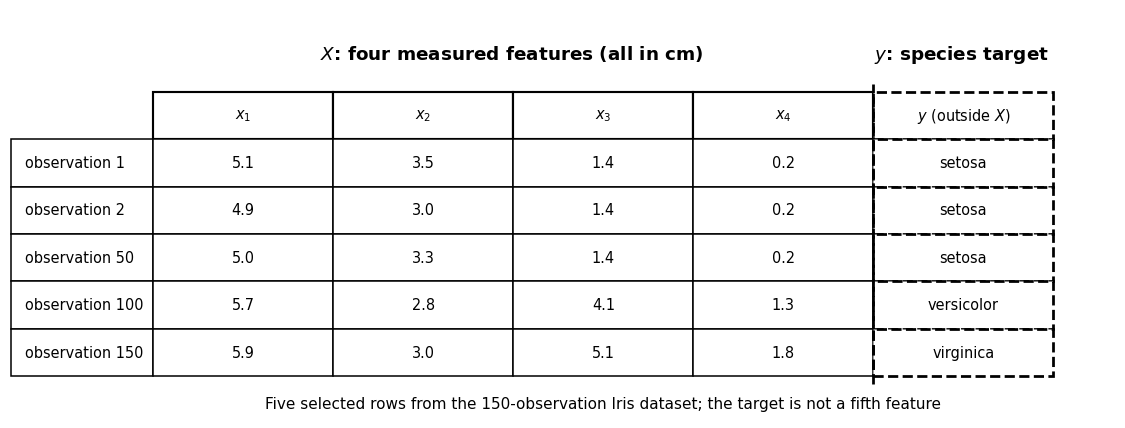

,Python expression,Mathematical role,shape
0,X,feature matrix,"(150, 4)"
1,"X[149:150, :]",observation 150 as a row matrix,"(1, 4)"
2,"X[:, 0:1]",feature 1 as a column matrix,"(150, 1)"
3,y,target vector,"(150,)"


x_1^(150), sepal length of observation 150: 5.9 cm
y^(150): code 2 -> virginica


In [6]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_table = iris.frame.copy()
iris_table["species"] = iris_table["target"].map(dict(enumerate(iris.target_names)))

X = iris.data.to_numpy()
y = iris.target.to_numpy()

feature_dictionary = pd.DataFrame(
    {
        "X column": [1, 2, 3, 4],
        "feature": iris.feature_names,
        "unit": ["cm"] * 4,
        "NumPy selection": ["X[:, 0]", "X[:, 1]", "X[:, 2]", "X[:, 3]"],
    }
)
display(feature_dictionary)

target_dictionary = pd.DataFrame(
    {
        "target code in y": np.arange(len(iris.target_names)),
        "species label": iris.target_names,
        "mathematical role": ["class target"] * len(iris.target_names),
    }
)
display(target_dictionary)

selected_rows = np.array([0, 1, 49, 99, 149])
display(iris_table.iloc[selected_rows])

# Original matrix schematic built from five actual Iris observations.
schematic_values = []
for row_index in selected_rows:
    schematic_values.append(
        [*(f"{value:.1f}" for value in X[row_index]), iris.target_names[y[row_index]]]
    )

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis("off")
matrix_table = ax.table(
    cellText=schematic_values,
    colLabels=["$x_1$", "$x_2$", "$x_3$", "$x_4$", "$y$ (outside $X$)"],
    rowLabels=[f"observation {index + 1}" for index in selected_rows],
    cellLoc="center",
    colLoc="center",
    bbox=[0.06, 0.10, 0.88, 0.70],
)
matrix_table.auto_set_font_size(False)
matrix_table.set_fontsize(9.5)
for (row, col), cell in matrix_table.get_celld().items():
    cell.set_edgecolor("black")
    if col == 4:
        cell.set_linewidth(1.8)
        cell.set_linestyle("--")
    elif row == 0:
        cell.set_linewidth(1.4)

ax.plot([0.764, 0.764], [0.08, 0.82], transform=ax.transAxes, color="black", linestyle="--", linewidth=1.8)
ax.text(0.41, 0.88, "$X$: four measured features (all in cm)", transform=ax.transAxes, ha="center", fontsize=12, weight="bold")
ax.text(0.85, 0.88, "$y$: species target", transform=ax.transAxes, ha="center", fontsize=12, weight="bold")
ax.text(0.50, 0.02, "Five selected rows from the 150-observation Iris dataset; the target is not a fifth feature", transform=ax.transAxes, ha="center", fontsize=10)
plt.show()

shape_check = pd.DataFrame(
    {
        "Python expression": ["X", "X[149:150, :]", "X[:, 0:1]", "y"],
        "Mathematical role": ["feature matrix", "observation 150 as a row matrix", "feature 1 as a column matrix", "target vector"],
        "shape": [str(X.shape), str(X[149:150, :].shape), str(X[:, 0:1].shape), str(y.shape)],
    }
)
display(shape_check)

print(f"x_1^(150), sepal length of observation 150: {X[149, 0]:.1f} cm")
print(f"y^(150): code {y[149]} -> {iris.target_names[y[149]]}")

The first table maps the four columns of $\mathbf{X}$ to their centimeter-based measurements and exact NumPy selections. The second table preserves the mapping from integer target codes 0-2 to the three species labels. The sample rows and matrix schematic make the observation-feature arrangement visible: the dashed boundary places $y$ outside the four columns of $\mathbf{X}$ rather than treating species as a fifth feature. The shape table verifies the textbook dimensions: `X` has 150 rows and four feature columns. Observation 150 remains two-dimensional when written as `X[149:150, :]`, with shape `(1, 4)`. The first feature remains a column matrix when written as `X[:, 0:1]`, with shape `(150, 1)`. Python uses zero-based indexing, so mathematical observation 150 appears at index 149.

The integer target codes are implementation conveniences. Their mapping to species must be preserved; numerical operations on 0, 1, and 2 do not define biological distance among species.

**Reasoning check.** A table has 20,000 transactions from 2,500 customers. Before declaring $n=20{,}000$, what is the intended observation unit, and how could repeated customers affect a train/test split?

## Issue 5 - Where is the boundary between fitting and final evaluation?

A predictive workflow is more than a learning algorithm:

1. define the intended use, observation unit, features, target, and error consequences;
2. collect and inspect authorized data;
3. reserve a test set that represents the intended future use;
4. use the remaining development data to fit preprocessing, compare models, and choose hyperparameters;
5. apply the completed process to the reserved test set for final evaluation; and
6. apply the same fitted preprocessing and model to new observations.

The workflow diagram below makes two paths explicit. Development data can inform preprocessing, fitting, and candidate selection. The reserved test set enters only after the procedure has been fixed. If a test result sends the team back to change the procedure, that set has become development evidence and is no longer untouched final evidence.

> **Before running the next cell:** Predict which stage may change the procedure and which stage may not. In the diagram, identify the data path that must not provide feedback to candidate development.

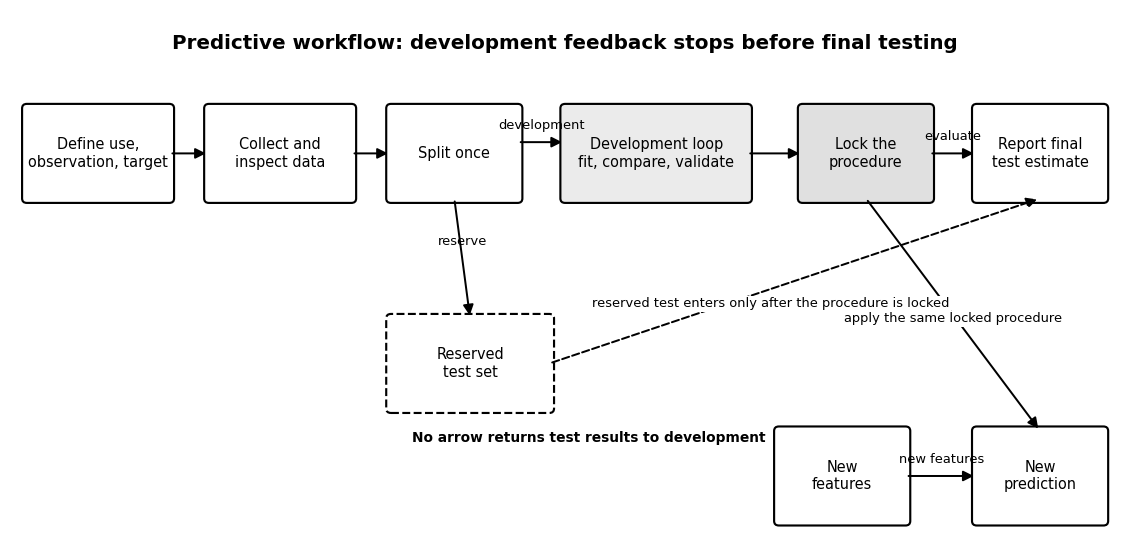

,stage,data used,may fit or select the procedure?,main result
0,Development,training and validation portions,Yes,locked procedure
1,Final evaluation,reserved test features and targets,No,final test estimate
2,Prediction on new data,new features; target not yet known,No,new prediction


In [7]:
# Course-added predictive-workflow diagram and information-use table.
fig, ax = plt.subplots(figsize=(13, 6.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")

def workflow_box(x, y, width, height, text, facecolor="white", linestyle="-"):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.06",
        linewidth=1.4,
        edgecolor="black",
        facecolor=facecolor,
        linestyle=linestyle,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=9.5)

def workflow_arrow(start, end, label=None, linestyle="-"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14, linewidth=1.3, linestyle=linestyle, color="black"))
    if label:
        ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.18, label, ha="center", fontsize=8.5)

workflow_box(0.2, 4.5, 1.8, 1.2, "Define use,\nobservation, target")
workflow_box(2.5, 4.5, 1.8, 1.2, "Collect and\ninspect data")
workflow_box(4.8, 4.5, 1.6, 1.2, "Split once")
workflow_box(7.0, 4.5, 2.3, 1.2, "Development loop\nfit, compare, validate", facecolor="0.92")
workflow_box(10.0, 4.5, 1.6, 1.2, "Lock the\nprocedure", facecolor="0.88")
workflow_box(12.2, 4.5, 1.6, 1.2, "Report final\ntest estimate")
workflow_box(4.8, 1.7, 2.0, 1.2, "Reserved\ntest set", linestyle="--")
workflow_box(9.7, 0.2, 1.6, 1.2, "New\nfeatures")
workflow_box(12.2, 0.2, 1.6, 1.2, "New\nprediction")

workflow_arrow((2.0, 5.1), (2.5, 5.1))
workflow_arrow((4.3, 5.1), (4.8, 5.1))
workflow_arrow((6.4, 5.25), (7.0, 5.25), "development")
workflow_arrow((9.3, 5.1), (10.0, 5.1))
workflow_arrow((11.6, 5.1), (12.2, 5.1), "evaluate")
workflow_arrow((5.6, 4.5), (5.8, 2.9), "reserve")
workflow_arrow((6.8, 2.3), (13.0, 4.5), linestyle="--")
workflow_arrow((11.3, 0.8), (12.2, 0.8), "new features")
workflow_arrow((10.8, 4.5), (13.0, 1.4))

ax.text(7.0, 6.5, "Predictive workflow: development feedback stops before final testing", ha="center", fontsize=13, weight="bold")
ax.text(
    9.6, 3.05,
    "reserved test enters only after the procedure is locked",
    ha="center", fontsize=8.5,
    bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0},
)
ax.text(7.3, 1.25, "No arrow returns test results to development", ha="center", fontsize=9, weight="bold")
ax.text(
    11.9, 2.85,
    "apply the same locked procedure",
    ha="center", fontsize=8.5,
    bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0},
)
plt.show()

information_use = pd.DataFrame(
    {
        "stage": ["Development", "Final evaluation", "Prediction on new data"],
        "data used": ["training and validation portions", "reserved test features and targets", "new features; target not yet known"],
        "may fit or select the procedure?": ["Yes", "No", "No"],
        "main result": ["locked procedure", "final test estimate", "new prediction"],
    }
)
display(information_use)

The table identifies development as the only displayed stage that may fit or select the procedure. Final evaluation uses reserved test features and targets after the procedure is locked, and prediction on new data uses features before the target is known. The dashed route carries the reserved test set forward to final evaluation; there is deliberately no arrow from the reported test estimate back to the development loop. This is a conceptual workflow, not a claim that every project uses one particular split ratio or validation method.

### Train-fitted scaling

The textbook states that test and future observations must reuse transformations fitted on training data. The equations below are course-added expansions of that requirement.

If feature $j$ is standardized, its training mean and standard deviation are

$$
\mu_j^{\text{train}}=\frac{1}{n_{\text{train}}}
\sum_{i\in\text{train}}x_j^{(i)},
$$

$$
\sigma_j^{\text{train}}=
\sqrt{\frac{1}{n_{\text{train}}}
\sum_{i\in\text{train}}
\left(x_j^{(i)}-\mu_j^{\text{train}}\right)^2}.
$$

For a nonconstant feature with $\sigma_j^{\text{train}}>0$, the transformation applied to training, validation, test, and future observations is then

$$
z_j=\frac{x_j-\mu_j^{\text{train}}}{\sigma_j^{\text{train}}}.
$$

For min-max scaling to $[0,1]$, the corresponding train-fitted formula is

$$
x'_j=\frac{x_j-\min_{\text{train}}(x_j)}
{\max_{\text{train}}(x_j)-\min_{\text{train}}(x_j)}.
$$

This min-max formula requires $\max_{\text{train}}(x_j)>\min_{\text{train}}(x_j)$. A constant feature makes either scaling denominator zero and must be handled explicitly rather than divided by zero.

If test observations help determine these quantities, information from the final evaluation data has entered model development. This is data leakage even when the target column was never used.

> **Before running the next cell:** In the artificial example, the test value is far outside the training range. Predict whether including that test value when calculating the mean and standard deviation will make its standardized value appear more or less extreme.

In [8]:
# Artificial teaching example: the value 100 is deliberately outside the training range.
train_feature = np.array([1.0, 2.0, 3.0, 4.0])
test_feature = np.array([100.0])

train_mean = train_feature.mean()
train_std = train_feature.std(ddof=0)
correct_test_z = (test_feature[0] - train_mean) / train_std

all_values = np.concatenate([train_feature, test_feature])
leaked_mean = all_values.mean()
leaked_std = all_values.std(ddof=0)
leaked_test_z = (test_feature[0] - leaked_mean) / leaked_std

pd.DataFrame(
    {
        "calculation": ["Fit scaling on training only", "Fit scaling on training + test (leakage)"],
        "mean used": [train_mean, leaked_mean],
        "standard deviation used": [train_std, leaked_std],
        "standardized test value": [correct_test_z, leaked_test_z],
    }
).round(3)

,calculation,mean used,standard deviation used,standardized test value
0,Fit scaling on training only,2.5,1.118,87.207
1,Fit scaling on training + test (leakage),22.0,39.013,1.999


With training-only fitting, the mean is `2.500`, the standard deviation is `1.118`, and the test value becomes `87.207` standardized units from the mean. When the test value is improperly included, the fitted mean changes to `22.000`, the standard deviation changes to `39.013`, and the same test value appears only `1.999` units from the mean. The example is intentionally exaggerated so that the leakage mechanism is visible. It does not estimate how much leakage will change a particular real model.

The same boundary applies to imputation, feature selection, dimensionality reduction, and other operations that learn quantities from data: fit them on the permitted training portion, then reuse the fitted transformation elsewhere.

**Reasoning check.** Why is "we never used the test labels" insufficient evidence that preprocessing was leakage-free?

## Issue 6 - What does an evaluation number mean?

Training performance describes data used to fit parameters. Validation performance supports comparisons among candidate procedures. Test performance estimates how the already selected procedure behaves on reserved observations. Reusing one set for all three purposes weakens the interpretation.

For classification, the textbook defines accuracy verbally as the proportion classified correctly. The following equation is the course-added mathematical form of that definition:

$$
\operatorname{Accuracy}
=\frac{\text{number of correctly classified observations}}
{\text{number of evaluated observations}}
=\frac{1}{n}\sum_{i=1}^{n}\mathbb{1}\!\left(y^{(i)}=\hat y^{(i)}\right),
$$

where the indicator $\mathbb{1}(\cdot)$ equals 1 when the statement is true and 0 otherwise. Accuracy weights every evaluated observation equally. It can conceal which classes are harmed or which mistakes have greater consequences.

More generally, the following course-added equation writes a finite test-set average loss:

$$
\widehat{R}_{\text{test}}(f)
=\frac{1}{n_{\text{test}}}
\sum_{i\in\text{test}}L\!\left(y^{(i)},f(\mathbf{x}^{(i)})\right).
$$

Both averages require a nonempty evaluation set. The test average is an estimate for data represented by the test design, not a guarantee for every future population. Model assumptions matter: the no-free-lunch result discussed in the chapter rules out a universally best learning algorithm when no assumptions about the task are made.

> **Before running the next cell:** The demonstration uses only Iris sepal length and width, which overlap across species. Predict which candidate will have higher validation accuracy. Also predict whether the highest training accuracy must identify the selected candidate. If validation accuracy is exactly tied, the demonstration uses the first predeclared candidate, logistic regression, only to make the execution deterministic; a tie is not evidence of superiority.

In [9]:
# Course-added workflow preview. Detailed model selection is taught in Chapter 6.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_two = X[:, :2]  # sepal length and sepal width, both measured in centimeters
X_development, X_test, y_development, y_test = train_test_split(
    X_two, y, test_size=0.20, random_state=17, stratify=y
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development, y_development, test_size=0.20, random_state=17, stratify=y_development
)

# Make the preprocessing calculation visible and fit it only on training data.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0, ddof=0)
X_train_z = (X_train - train_mean) / train_std
X_validation_z = (X_validation - train_mean) / train_std

candidates = {
    "logistic regression": LogisticRegression(max_iter=1000, random_state=17),
    "5-nearest neighbors": KNeighborsClassifier(n_neighbors=5),
}

rows = []
for name, model in candidates.items():
    model.fit(X_train_z, y_train)
    rows.append(
        {
            "candidate": name,
            "training accuracy": model.score(X_train_z, y_train),
            "validation accuracy": model.score(X_validation_z, y_validation),
        }
    )

comparison = pd.DataFrame(rows).sort_values(
    "validation accuracy", ascending=False, kind="stable"
).reset_index(drop=True)
display(comparison.round(3))

selected_name = comparison.loc[0, "candidate"]

# After selection, refit the selected procedure on all development data.
development_mean = X_development.mean(axis=0)
development_std = X_development.std(axis=0, ddof=0)
X_development_z = (X_development - development_mean) / development_std
X_test_z = (X_test - development_mean) / development_std

selected_model = candidates[selected_name]
selected_model.fit(X_development_z, y_development)
test_accuracy = selected_model.score(X_test_z, y_test)

print(f"Selected by validation accuracy: {selected_name}")
print(f"Final reserved-test accuracy: {test_accuracy:.3f} ({int(test_accuracy * len(y_test))}/{len(y_test)} correct)")

,candidate,training accuracy,validation accuracy
0,logistic regression,0.833,0.917
1,5-nearest neighbors,0.844,0.917


Selected by validation accuracy: logistic regression
Final reserved-test accuracy: 0.700 (21/30 correct)


Both candidates obtain validation accuracy `0.917` in this execution, although 5-nearest neighbors has slightly higher training accuracy (`0.844` versus `0.833`). The predeclared tie rule therefore selects logistic regression; the tie does not establish that it is the better algorithm. After refitting on all development data, logistic regression correctly classifies 21 of 30 reserved test observations, for test accuracy `0.700`. Read this as one estimate under this exact split, two-feature representation, and selection rule, not as proof of general superiority. Chapter 6 will add cross-validation, uncertainty, tuning, and a broader set of metrics.

**Reasoning check.** If you inspect the test result and then change the features or candidate list, what role has the test set begun to play? What new evidence would be required for an untouched final estimate?

## Issue 7 - Can another person reproduce the environment and the claim?

The textbook was written against an earlier software environment. Exact version matching is sometimes useful for reproducing published code, but a course notebook should also record the environment in which its current outputs were actually produced.

This semester's approved scope is Chapters 1-10. Those chapters primarily use Python, NumPy, pandas, Matplotlib, SciPy, and scikit-learn. PyTorch begins later in the textbook and is not required for this machine-learning semester unless the instructor changes the scope.

Run the following cell without editing its output. If your versions differ, differences are not automatically errors; they are evidence to preserve when numerical or API behavior changes.

In [10]:
import platform
import sys
import matplotlib
import numpy
import pandas
import scipy
import sklearn

pd.DataFrame(
    {
        "component": ["Python", "NumPy", "pandas", "SciPy", "scikit-learn", "Matplotlib", "platform"],
        "version or value": [
            platform.python_version(),
            numpy.__version__,
            pandas.__version__,
            scipy.__version__,
            sklearn.__version__,
            matplotlib.__version__,
            platform.platform(),
        ],
    }
)

,component,version or value
0,Python,3.12.9
1,NumPy,2.2.6
2,pandas,2.2.3
3,SciPy,1.17.1
4,scikit-learn,1.8.0
5,Matplotlib,3.10.8
6,platform,Windows-11-10.0.26200-SP0


The verified notebook records Python `3.12.9`, NumPy `2.2.6`, pandas `2.2.3`, SciPy `1.17.1`, scikit-learn `1.8.0`, and Matplotlib `3.10.8` on Windows 11. These are the versions that produced the preserved outputs, not the publication-era versions listed in the textbook.

For a reproducible result, versions alone are not enough. Preserve the data source and date, observation unit, target definition, feature transformations, split procedure, random seed, candidate procedures, selection rule, metric, actual outputs, and known limitations.

If you create a local virtual environment, use either `venv` with `pip` or a conda-compatible environment manager. Do not mix installation commands into the analytical cells of this notebook. Environment creation should occur before the notebook is opened, and package changes should be recorded rather than silently applied while results are being produced.

<details>
<summary>One Windows venv setup route</summary>

Run these commands in a terminal from the folder where you want the environment. They are setup commands, not notebook cells.

```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install numpy scipy pandas matplotlib scikit-learn jupyterlab
python -m jupyter lab
```

If PowerShell policy prevents activation, do not weaken the computer's security settings. Use the environment's Python executable directly or ask the instructor which managed environment is available.

</details>

## Two integrative discussion questions

### Question 1 - Is the final number still a test estimate?

A team reports 98% training accuracy, 92% validation accuracy, and 87% test accuracy. It then reveals that missing-value replacement, scaling, and feature selection were all fitted once on the complete dataset before the split. Can the 87% value still be presented as an untouched estimate of generalization? Identify every information-boundary violation, specify exactly what must be rerun, and state what evidence would allow a new final estimate to be interpreted.

### Question 2 - Define the learning problem before choosing a model

A university has 12,000 historical course-enrollment records from 4,100 students. It wants to identify, before Week 3, enrollments that may end in withdrawal so that an adviser can offer support. Define the observation unit, $\mathbf{X}$, $\mathbf{y}$, prediction time, and learning type. Then specify a split that prevents the same student's records from making evaluation artificially easy, one metric that accuracy alone would miss, one plausible harm from an incorrect prediction, and one finding that should stop deployment even if validation accuracy is high.

## Evidence to preserve

Keep your written predictions from before execution, the executed notebook with its tables and figures, the environment table, and short answers to the reasoning checks. For your project record, add one candidate problem with an observation unit, possible features, a target or other learning signal, the time at which a prediction or action would occur, and one reason the available data may not support the intended use.

## Chapter summary

Machine learning begins with a learning signal, a defined observation, and a claim that can be checked on data not used to fit the procedure. Supervised learning predicts known targets; classification predicts categories and regression predicts continuous quantities. Unsupervised learning can expose structure without known targets, while reinforcement learning concerns actions and rewards across interactions. Matrix notation makes the data arrangement explicit, and the predictive workflow protects the distinction between fitting, selection, and final evaluation.

Chapter 2 moves from this overview to the perceptron and Adaline. It will make the linear score, threshold decision, loss function, and parameter-update process explicit.

### Source note

The chapter structure and established terminology follow Chapter 1 of Sebastian Raschka, Yuxi (Hayden) Liu, and Vahid Mirjalili, *Machine Learning with PyTorch and Scikit-Learn* (2022). Mathematical bridges and executable demonstrations identified as course-added were written for this course. The Iris data loaded by scikit-learn contain 150 observations, four centimeter-based features, and three species labels.